# Análisis Exploratorio de Metadatos (EDA)
## Dataset EMG: grupo de sujetos intactos

Este notebook documenta el análisis exploratorio de los metadatos del grupo de sujetos **intactos** del proyecto EMG. El objetivo es describir la composición de la muestra, revisar la distribución de sus variables demográficas y antropométricas, evaluar cómo cambian estas variables al estratificar por género, categoría de IMC, lateralidad y base de datos de origen, y finalmente explorar sus relaciones conjuntas mediante un análisis multivariado.

La lectura está organizada como un informe técnico: primero se presenta el contexto del análisis (sección 1), luego se describe el grupo de forma general (sección 2), después se analiza cómo varían sus variables antropométricas al estratificar por distintas variables categóricas (sección 3), y finalmente se exploran las relaciones conjuntas entre variables numéricas (sección 4).

### Variables revisadas
- Género
- Lateralidad
- Edad
- Peso
- Altura
- Índice de masa corporal (IMC)
- Base de datos de origen


## 1. Carga de librerías y datos

En esta sección se importan las librerías necesarias para el análisis (incluyendo `scikit-learn` para el análisis multivariado de la sección 4) y se cargan los archivos maestros con los metadatos de los dos grupos de estudio. El grupo amputado se carga solo como referencia para la verificación de consistencia de la sección 1.1; el resto del notebook trabaja exclusivamente sobre el grupo intacto.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np

# Cargar datos
intact = pd.read_csv('../data/master/intact_subjects.csv')
amputated = pd.read_csv('../data/master/amputated_subjects.csv')

##### 1.1 Verificación de calidad de los datos

Antes de iniciar el análisis descriptivo se revisa que no existan sujetos duplicados dentro de una misma base de datos, que las categorías de variables compartidas (género, lateralidad, mano) estén escritas de forma consistente entre ambos dataframes, y que los rangos de edad, peso y altura sean fisiológicamente plausibles. Esto es especialmente relevante porque los datos provienen de fuentes distintas y pequeñas inconsistencias de codificación pueden pasar desapercibidas al combinarlos más adelante.

In [2]:
dup_intact = intact.duplicated(subset=['Subject', 'Database']).sum()
dup_amputated = amputated.duplicated(subset=['Subject', 'Database']).sum()
print(f'Sujetos duplicados (Subject + Database) - Intacto: {dup_intact}')
print(f'Sujetos duplicados (Subject + Database) - Amputado: {dup_amputated}')

print('\nValores únicos de Handedness:')
print('Intacto:', sorted(intact['Handedness'].unique()))
print('Amputado:', sorted(amputated['Handedness'].unique()))

print('\nValores únicos de Gender:')
print('Intacto:', sorted(intact['Gender'].unique()))
print('Amputado:', sorted(amputated['Gender'].unique()))

print('\nRangos de Edad / Altura / Peso:')
print(intact[['Age', 'Height', 'Weight']].agg(['min', 'max']))
print(amputated[['Age', 'Height', 'Weight']].agg(['min', 'max']))

Sujetos duplicados (Subject + Database) - Intacto: 0
Sujetos duplicados (Subject + Database) - Amputado: 0

Valores únicos de Handedness:
Intacto: ['Left', 'Right']
Amputado: ['Left', 'Right']

Valores únicos de Gender:
Intacto: ['Female', 'Male']
Amputado: ['Female', 'Male']

Rangos de Edad / Altura / Peso:
     Age  Height  Weight
min   20     155      44
max   54     192     105
     Age  Height  Weight
min   28     166      66
max   67     185      95


## 2. Análisis descriptivo general del grupo intacto

Esta sección describe la muestra de sujetos intactos variable por variable. Primero se revisa la estructura general del dataframe y después se analizan sus variables categóricas y numéricas para obtener una lectura inicial de la composición del grupo, antes de cruzarlas entre sí en la sección 3.


#### 2.1 Resumen general

Se revisa la estructura del conjunto de datos, los tipos de variables disponibles y los estadísticos básicos que permiten ubicar el perfil general de la muestra.

In [3]:
intact.head()

,Subject,Hand,Handedness,Gender,Age,Height,Weight,Database
0,1,Intact,Right,Male,31,170,75,DB1
1,2,Intact,Right,Male,27,170,62,DB1
2,3,Intact,Right,Male,22,180,85,DB1
3,4,Intact,Right,Male,27,183,95,DB1
4,5,Intact,Right,Male,27,178,75,DB1


In [4]:
intact.info()

<class 'pandas.DataFrame'>
RangeIndex: 107 entries, 0 to 106
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Subject     107 non-null    int64
 1   Hand        107 non-null    str  
 2   Handedness  107 non-null    str  
 3   Gender      107 non-null    str  
 4   Age         107 non-null    int64
 5   Height      107 non-null    int64
 6   Weight      107 non-null    int64
 7   Database    107 non-null    str  
dtypes: int64(4), str(4)
memory usage: 6.8 KB


In [5]:
intact.describe() 

,Subject,Age,Height,Weight
count,107.000000,107.000000,107.000000,107.000000
mean,14.186916,28.887850,173.878505,70.794393
std,10.267306,4.753007,8.689302,12.251868
min,1.000000,20.000000,155.000000,44.000000
25%,6.000000,26.000000,169.000000,63.000000
50%,12.000000,29.000000,173.000000,70.000000
75%,20.500000,30.000000,180.000000,77.000000
max,40.000000,54.000000,192.000000,105.000000


In [6]:
# Función para calcular el porcentaje y mostrar la cantidad
def formatear_etiqueta(pct):
    total = sum(valores)
    absoluto = int(round(pct * total / 100.0))
    return f'{pct:.0f}%\n({absoluto})'  # Muestra: "X% \n (Cantidad)"

#### 2.2 Variables categóricas

Se revisan las variables categóricas más importantes del grupo intacto: género y lateralidad. Estas dos dimensiones permiten entender la composición general de la muestra y verificar si existe equilibrio entre categorías o predominio de algún subgrupo.

##### 2.2.1 Distribución del género

Se revisa primero el balance de género de la muestra, ya que es la variable demográfica más básica y sirve como punto de referencia antes de cruzarla con otras variables más adelante.


Text(0.5, 1.0, 'Distribución del género - Grupo intacto')

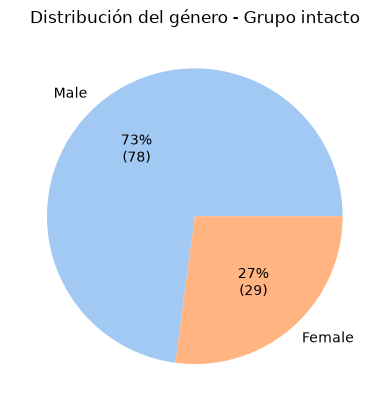

In [7]:
colores = sns.color_palette('pastel')
valores = intact['Gender'].value_counts().values
etiquetas = intact['Gender'].value_counts().index

plt.pie(valores, labels=etiquetas, colors=colores, autopct=formatear_etiqueta)
plt.title('Distribución del género - Grupo intacto')


##### 2.2.2 Distribución de la lateralidad

La lateralidad es una variable relevante porque puede influir en la selección de sujetos y en la interpretación posterior de las señales. Este gráfico permite ver si la muestra está dominada por sujetos diestros, zurdos o si existe una distribución equilibrada.

Text(0.5, 1.0, 'Distribución de la lateralidad - Grupo intacto')

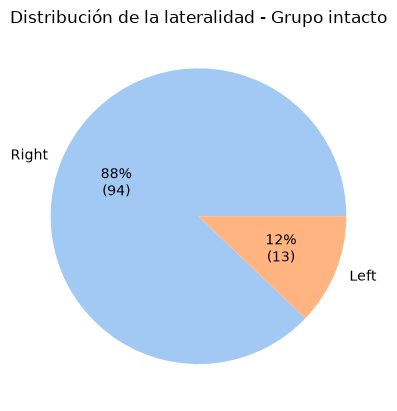

In [8]:
colores = sns.color_palette('pastel')
valores = intact['Handedness'].value_counts().values
etiquetas = intact['Handedness'].value_counts().index

plt.pie(valores, labels=etiquetas, colors=colores, autopct=formatear_etiqueta)
plt.title('Distribución de la lateralidad - Grupo intacto')


##### 2.2.3 Distribución por base de datos

Esta base agrupa sujetos provenientes de distintas bases de datos originales. Ver el porcentaje que aporta cada una permite dimensionar si el conjunto está dominado por una sola fuente o si la muestra está más repartida, algo relevante para interpretar correctamente los análisis estratificados por base de datos más adelante.

Text(0.5, 1.0, 'Porcentaje de sujetos por base de datos - Grupo intacto')

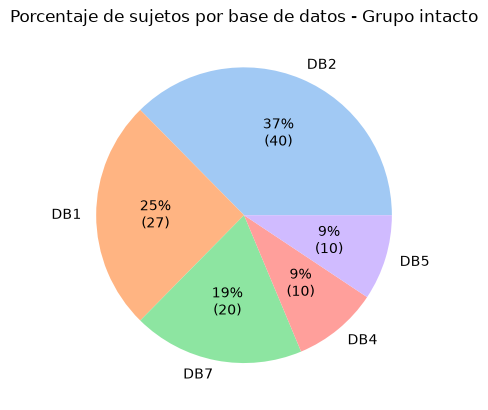

In [9]:
colores = sns.color_palette('pastel')
valores = intact['Database'].value_counts().values
etiquetas = intact['Database'].value_counts().index

plt.pie(valores, labels=etiquetas, colors=colores, autopct=formatear_etiqueta)
plt.title('Porcentaje de sujetos por base de datos - Grupo intacto')

##### 2.2.4 Base de datos y género

Se cruzan base de datos y género en una sola tabla para detectar si alguna base de datos aporta sujetos casi exclusivamente de un género, lo que podría sesgar cualquier comparación posterior que estratifique por género sin tener en cuenta el origen.

In [10]:
pd.crosstab(intact['Database'], intact['Gender'])

Gender,Female,Male
Database,,
DB1,7,20
DB2,11,29
DB4,4,6
DB5,2,8
DB7,5,15


#### 2.3 Variables antropométricas

Edad, peso y altura describen el perfil físico general de la muestra. Antes de comparar grupos o correlacionar variables, conviene revisar cómo se distribuyen estos valores y si existen asimetrías, concentraciones o posibles valores extremos.

Text(0, 0.5, 'Número de sujetos')

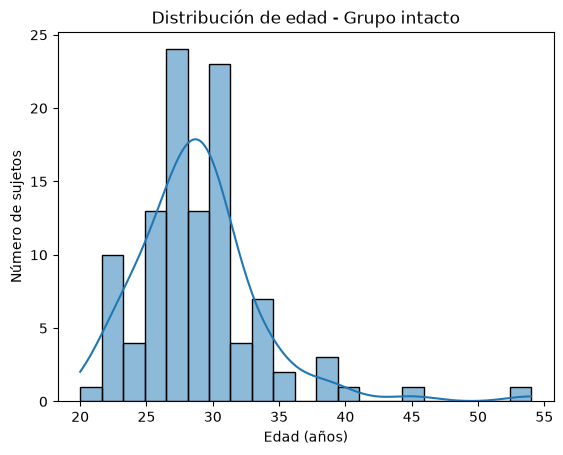

In [11]:
sns.histplot(intact['Age'].values, kde=True)
plt.title('Distribución de edad - Grupo intacto')
plt.xlabel('Edad (años)')
plt.ylabel('Número de sujetos')


Text(0, 0.5, 'Número de sujetos')

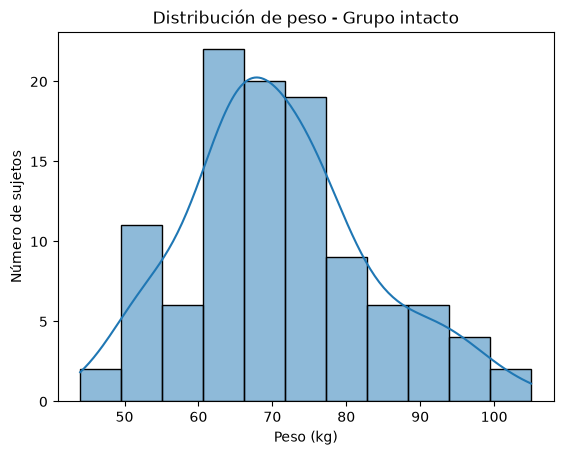

In [12]:
sns.histplot(intact['Weight'].values, kde=True)
plt.title('Distribución de peso - Grupo intacto')
plt.xlabel('Peso (kg)')
plt.ylabel('Número de sujetos')


Text(0, 0.5, 'Número de sujetos')

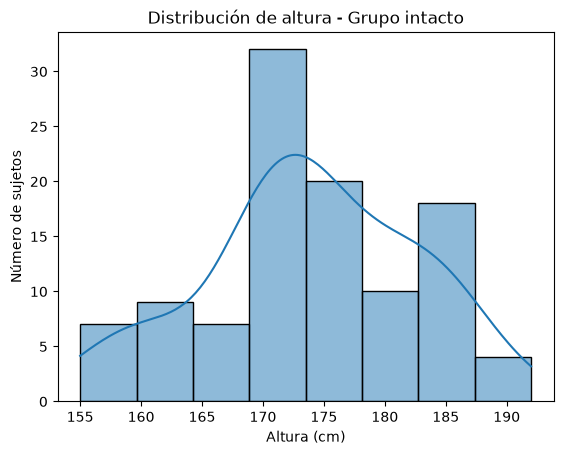

In [13]:
sns.histplot(intact['Height'].values, kde=True)
plt.title('Distribución de altura - Grupo intacto')
plt.xlabel('Altura (cm)')
plt.ylabel('Número de sujetos')


Text(0, 0.5, 'Densidad')

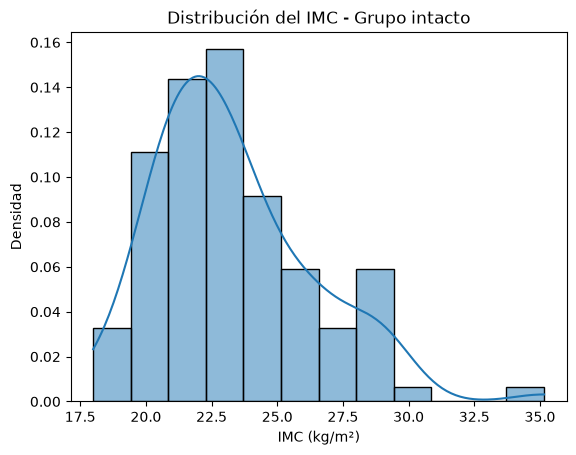

In [14]:
intact['BMI'] = intact['Weight'] / (intact['Height'] / 100) ** 2
sns.histplot(intact['BMI'], kde=True, stat='density')
plt.title('Distribución del IMC - Grupo intacto')
plt.xlabel('IMC (kg/m²)')
plt.ylabel('Densidad')


Text(0.5, 1.0, 'Clasificación del IMC - Grupo intacto')

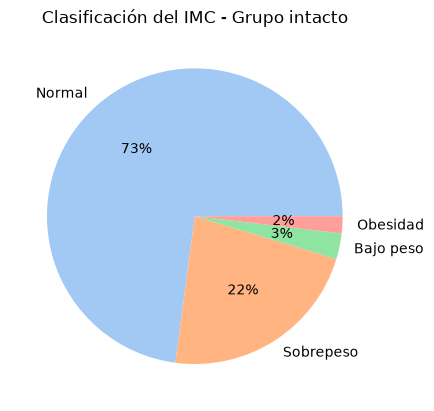

In [15]:
bins_imc = [0, 18.5, 25, 30, 100]
etiquetas_imc = ['Bajo peso', 'Normal', 'Sobrepeso', 'Obesidad']

intact['BMI Category'] = pd.cut(intact['BMI'], bins=bins_imc, labels=etiquetas_imc)

colores = sns.color_palette('pastel')
valores = intact['BMI Category'].value_counts().values
etiquetas = intact['BMI Category'].value_counts().index

plt.pie(valores, labels=etiquetas, colors=colores, autopct='%1.0f%%')
plt.title('Clasificación del IMC - Grupo intacto')

Text(0, 0.5, 'Número de sujetos')

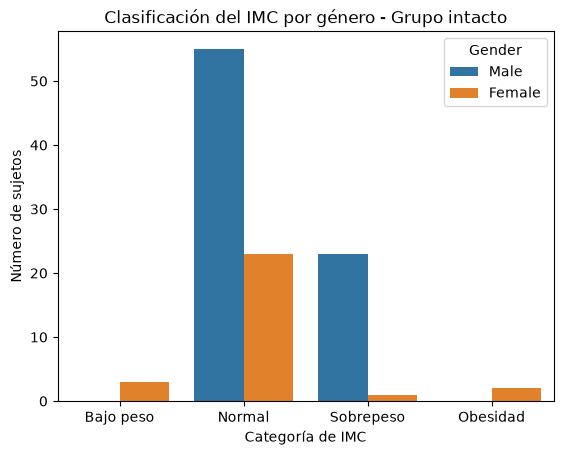

In [16]:
sns.countplot(data=intact, x='BMI Category', hue='Gender')
plt.title('Clasificación del IMC por género - Grupo intacto')
plt.xlabel('Categoría de IMC')
plt.ylabel('Número de sujetos')


Los histogramas anteriores muestran la distribución de edad, peso y altura en el grupo intacto. Esta lectura permite identificar la forma general de cada variable, observar si la muestra se concentra en ciertos rangos y detectar posibles diferencias de dispersión entre atributos antropométricos.

##### 2.3.1 Verificación de normalidad

Las tablas de media y desviación estándar que se usarán como referencia en la sección 3 asumen una distribución razonablemente simétrica. Aquí se aplica la prueba de Shapiro-Wilk sobre edad, peso y altura para verificar ese supuesto. Si alguna variable no se distribuye de forma normal, conviene tenerlo presente al interpretar la media como medida de tendencia central y considerar la mediana como alternativa más robusta.


In [17]:
from scipy import stats

for var in ['Age', 'Height', 'Weight']:
    stat, p = stats.shapiro(intact[var])
    resultado = 'se distribuye aprox. normal' if p > 0.05 else 'NO se distribuye normal'
    print(f'{var}: p-valor = {p:.3f} -> {resultado}')

Age: p-valor = 0.000 -> NO se distribuye normal
Height: p-valor = 0.095 -> se distribuye aprox. normal
Weight: p-valor = 0.065 -> se distribuye aprox. normal


## 3. Análisis estratificado del grupo intacto

Mientras que la sección 2 describe cada variable de forma aislada, esta sección cruza las variables antropométricas (edad, peso y altura) con cuatro variables categóricas de interés: género, categoría de IMC, lateralidad y base de datos de origen. El objetivo es identificar si alguna de ellas introduce diferencias sistemáticas en el perfil físico de la muestra, algo relevante para decidir si conviene usarlas como variables de estratificación en los análisis de señales posteriores.

Las primeras tres subsecciones (3.1 a 3.3) siguen la misma estructura breve: distribución, tabla de media y desviación estándar, y boxplots. La base de datos de origen (3.4 y 3.5) se trata con mayor profundidad porque combina múltiples fuentes de datos, así que primero se explora visualmente (3.4) y luego se consolida en tablas de referencia listas para citar en el artículo (3.5).


#### 3.1 Análisis estratificado por género

Este bloque compara edad, peso y altura entre géneros. El objetivo no es inferir causalidad, sino identificar si la composición física del grupo cambia de forma apreciable entre categorías y si conviene considerar el género como variable de estratificación en análisis posteriores.


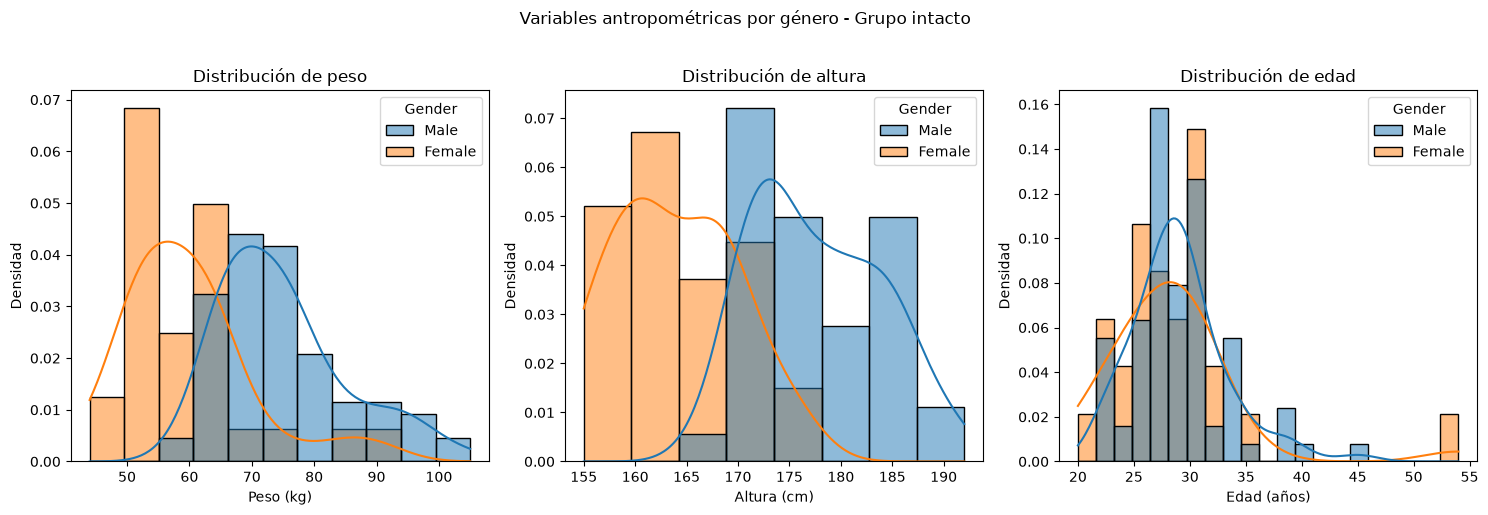

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(data=intact, x='Weight', hue='Gender', kde=True, stat='density', common_norm=False, ax=axes[0])
axes[0].set_title('Distribución de peso')
axes[0].set_xlabel('Peso (kg)')
axes[0].set_ylabel('Densidad')

sns.histplot(data=intact, x='Height', hue='Gender', kde=True, stat='density', common_norm=False, ax=axes[1])
axes[1].set_title('Distribución de altura')
axes[1].set_xlabel('Altura (cm)')
axes[1].set_ylabel('Densidad')

sns.histplot(data=intact, x='Age', hue='Gender', kde=True, stat='density', common_norm=False, ax=axes[2])
axes[2].set_title('Distribución de edad')
axes[2].set_xlabel('Edad (años)')
axes[2].set_ylabel('Densidad')

fig.suptitle('Variables antropométricas por género - Grupo intacto', y=1.02)
plt.tight_layout()


##### 3.1.1 Tabla resumen: media y desviación estándar por género

Esta tabla resume la distribución de edad, peso y altura agrupada únicamente por género, considerando todas las bases de datos de forma conjunta. Se presenta como referencia global para identificar diferencias antropométricas entre hombres y mujeres en la muestra total de sujetos intactos.


In [19]:
resumen_intact = intact.groupby('Gender').agg(
    n=('Subject', 'count'),
    Edad_media=('Age', 'mean'), Edad_de=('Age', 'std'),
    Altura_media=('Height', 'mean'), Altura_de=('Height', 'std'),
    Peso_media=('Weight', 'mean'), Peso_de=('Weight', 'std'),
).round(1)
resumen_intact

,n,Edad_media,Edad_de,Altura_media,Altura_de,Peso_media,Peso_de
Gender,,,,,,,
Female,29,28.4,6.1,163.9,5.9,59.7,10.0
Male,78,29.1,4.2,177.6,6.3,74.9,10.3


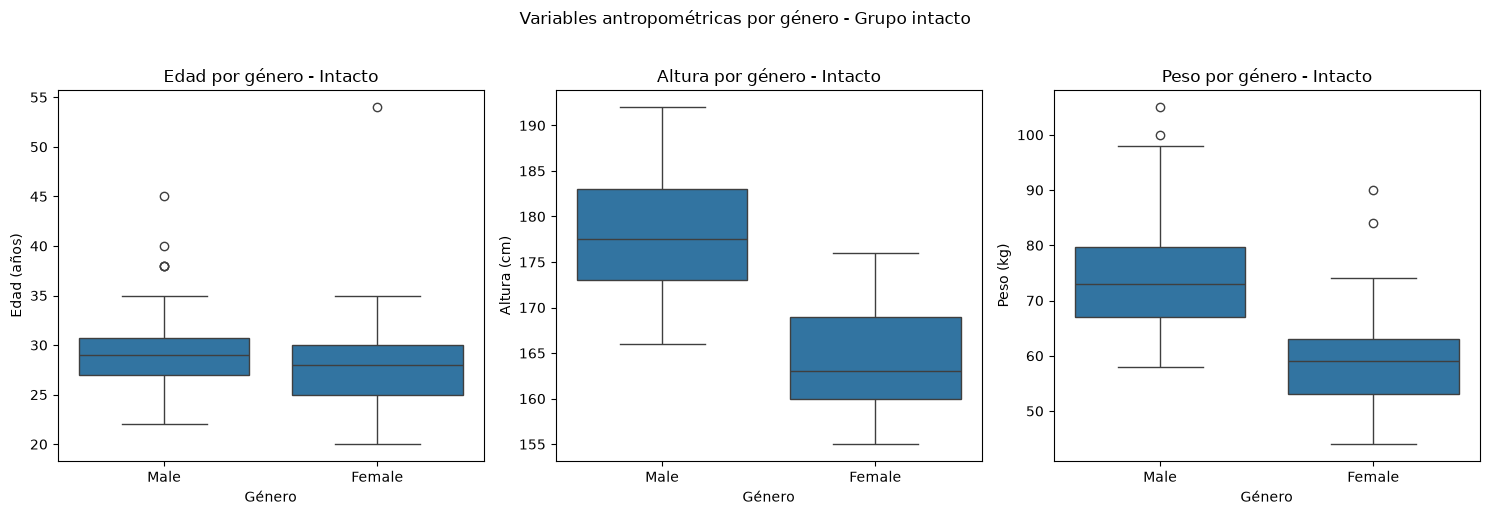

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.boxplot(x='Gender', y='Age', data=intact, ax=axes[0])
sns.boxplot(x='Gender', y='Height', data=intact, ax=axes[1])
sns.boxplot(x='Gender', y='Weight', data=intact, ax=axes[2])

unidades = {'Edad': 'años', 'Altura': 'cm', 'Peso': 'kg'}
for ax, titulo in zip(axes, ['Edad', 'Altura', 'Peso']):
    ax.set_title(f'{titulo} por género - Intacto')
    ax.set_xlabel('Género')
    ax.set_ylabel(f'{titulo} ({unidades[titulo]})')

fig.suptitle('Variables antropométricas por género - Grupo intacto', y=1.02)
plt.tight_layout()

##### 3.1.2 Edad por rango, cruzada con género y lateralidad

Agrupar la edad en rangos permite leer de un vistazo cómo se reparte cada subgrupo demográfico, algo más informativo que una única distribución continua cuando se combinan dos variables categóricas. Es importante recordar que el número de sujetos no es el mismo en cada base de datos, por lo que estas cifras deben leerse como proporciones dentro de cada grupo y no como conteos absolutos comparables entre bases.


Text(0.5, 1.05, 'Edad por rango, género y lateralidad - Grupo intacto')

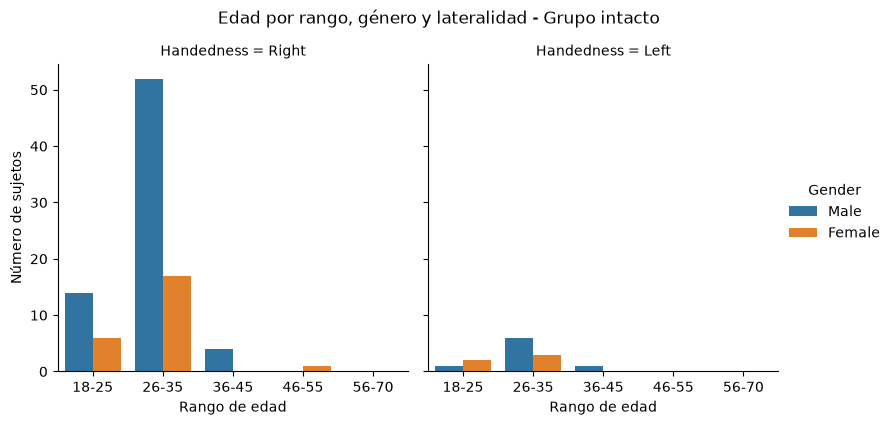

In [21]:
bins_edad = [17, 25, 35, 45, 55, 70]
etiquetas_edad = ['18-25', '26-35', '36-45', '46-55', '56-70']
intact['Age Group'] = pd.cut(intact['Age'], bins=bins_edad, labels=etiquetas_edad)

g = sns.catplot(
    data=intact, x='Age Group', hue='Gender', col='Handedness',
    kind='count', height=4, aspect=1
)
g.set_axis_labels('Rango de edad', 'Número de sujetos')
g.fig.suptitle('Edad por rango, género y lateralidad - Grupo intacto', y=1.05)

Los histogramas y boxplots por género ayudan a contrastar tendencia central, dispersión y posibles valores atípicos. Con esta vista se puede evaluar si la distribución de las variables antropométricas es similar entre géneros o si existen diferencias que deban tenerse en cuenta al comparar sujetos.

#### 3.2 Análisis estratificado por categoría de IMC

Este bloque compara edad, peso y altura entre las cuatro categorías de IMC (bajo peso, normal, sobrepeso y obesidad). El objetivo es identificar si el perfil antropométrico varía de forma apreciable entre categorías y si el IMC resulta una variable relevante para estratificar análisis posteriores.


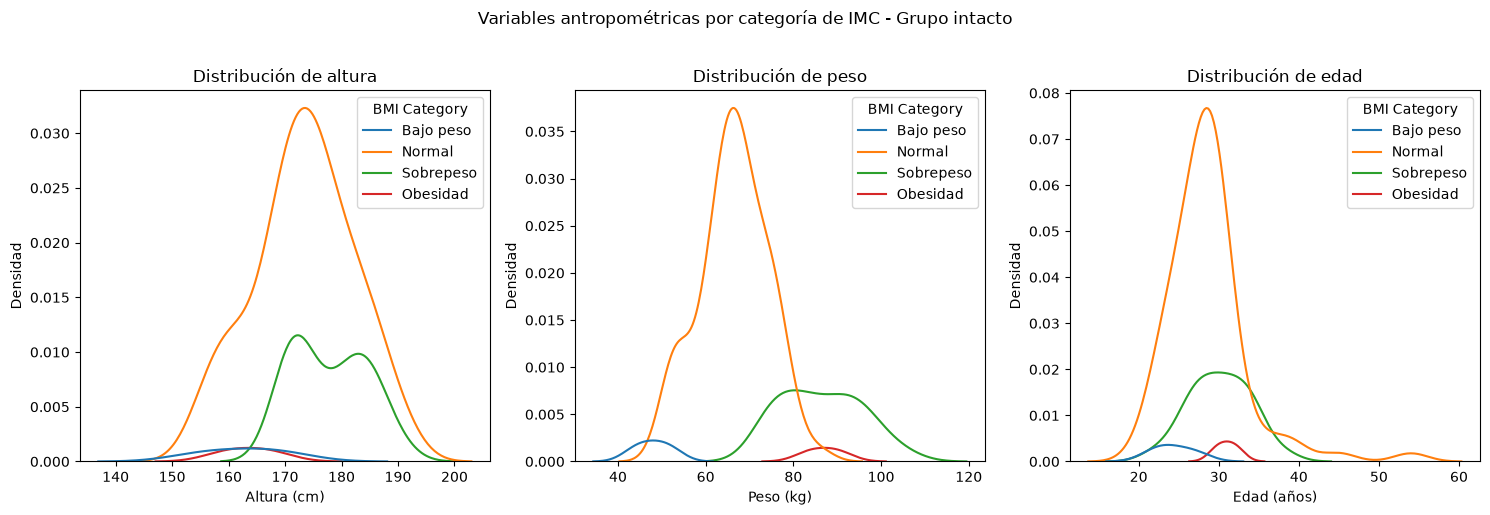

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.kdeplot(data=intact, x='Height', hue='BMI Category', ax=axes[0])
axes[0].set_title('Distribución de altura')
axes[0].set_xlabel('Altura (cm)')
axes[0].set_ylabel('Densidad')

sns.kdeplot(data=intact, x='Weight', hue='BMI Category', ax=axes[1])
axes[1].set_title('Distribución de peso')
axes[1].set_xlabel('Peso (kg)')
axes[1].set_ylabel('Densidad')

sns.kdeplot(data=intact, x='Age', hue='BMI Category', ax=axes[2])
axes[2].set_title('Distribución de edad')
axes[2].set_xlabel('Edad (años)')
axes[2].set_ylabel('Densidad')

fig.suptitle('Variables antropométricas por categoría de IMC - Grupo intacto', y=1.02)
plt.tight_layout()

##### 3.2.1 Tabla resumen: media y desviación estándar por categoría de IMC

Esta tabla resume la distribución de edad, peso y altura agrupada únicamente por categoría de IMC, considerando todas las bases de datos de forma conjunta. Se presenta como referencia global para identificar diferencias antropométricas entre personas con bajo peso, peso normal, sobrepeso y obesidad en la muestra total de sujetos intactos.


In [23]:
resumen_intact = intact.groupby('BMI Category').agg(
    n=('Subject', 'count'),
    Edad_media=('Age', 'mean'), Edad_de=('Age', 'std'),
    Altura_media=('Height', 'mean'), Altura_de=('Height', 'std'),
    Peso_media=('Weight', 'mean'), Peso_de=('Weight', 'std'),
).round(1)
resumen_intact

,n,Edad_media,Edad_de,Altura_media,Altura_de,Peso_media,Peso_de
BMI Category,,,,,,,
Bajo peso,3,24.3,2.5,162.7,7.5,48.0,4.0
Normal,78,28.6,5.0,173.3,8.8,66.4,7.7
Sobrepeso,24,30.1,3.8,177.9,6.5,86.4,9.1
Obesidad,2,31.0,1.4,163.5,4.9,87.0,4.2


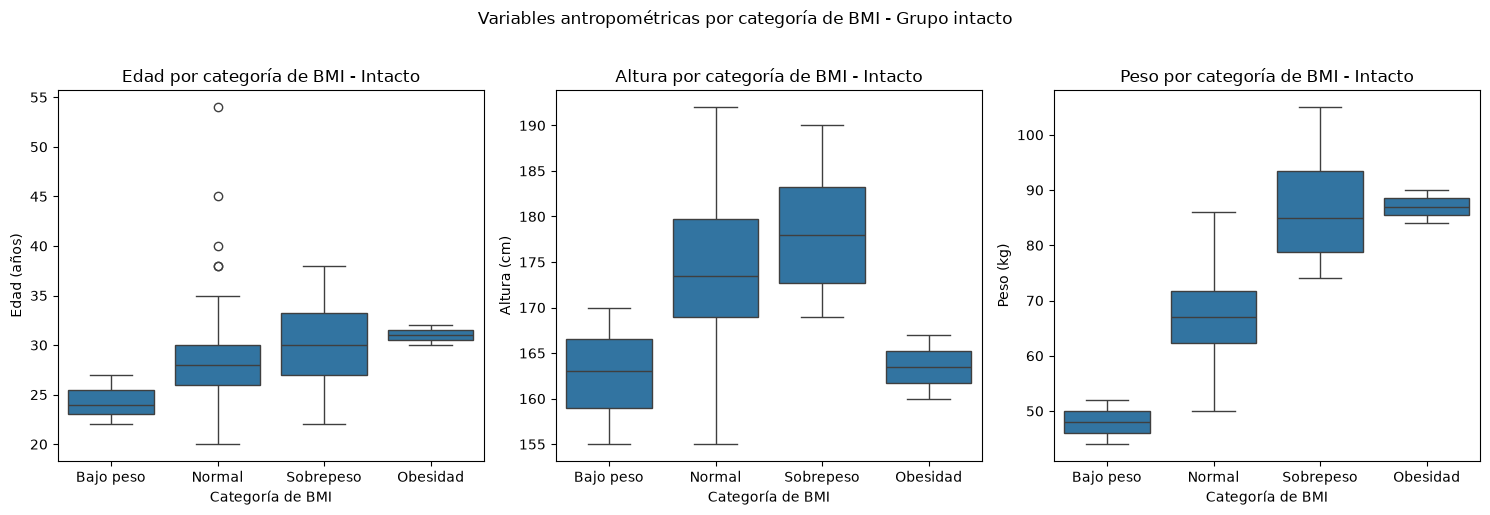

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.boxplot(x='BMI Category', y='Age', data=intact, ax=axes[0])
sns.boxplot(x='BMI Category', y='Height', data=intact, ax=axes[1])
sns.boxplot(x='BMI Category', y='Weight', data=intact, ax=axes[2])

unidades = {'Edad': 'años', 'Altura': 'cm', 'Peso': 'kg'}
for ax, titulo in zip(axes, ['Edad', 'Altura', 'Peso']):
    ax.set_title(f'{titulo} por categoría de BMI - Intacto')
    ax.set_xlabel('Categoría de BMI')
    ax.set_ylabel(f'{titulo} ({unidades[titulo]})')

fig.suptitle('Variables antropométricas por categoría de BMI - Grupo intacto', y=1.02)
plt.tight_layout()

##### 3.2.2 Edad por rango, cruzada con categoría de IMC y lateralidad

Se repite la misma lógica de la sección 3.1.2, cambiando el cruce de género por categoría de IMC, para revisar si el perfil etario de cada categoría nutricional también varía con la lateralidad reportada.


Text(0.5, 1.05, 'Edad por rango, categoría de IMC y lateralidad - Grupo intacto')

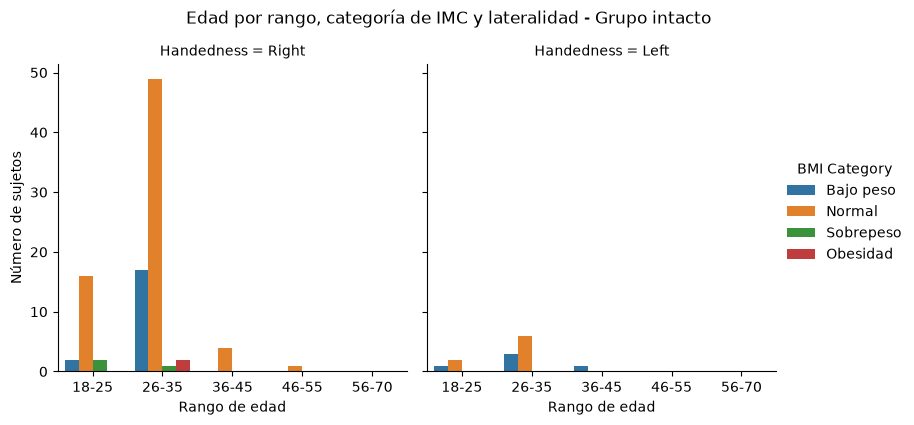

In [25]:
g = sns.catplot(
    data=intact, x='Age Group', hue='BMI Category', col='Handedness',
    kind='count', height=4, aspect=1
)
g.set_axis_labels('Rango de edad', 'Número de sujetos')
g.fig.suptitle('Edad por rango, categoría de IMC y lateralidad - Grupo intacto', y=1.05)


#### 3.3 Análisis estratificado por lateralidad

Este bloque compara edad, peso y altura entre grupos de lateralidad (diestros vs. zurdos). El objetivo es identificar si existen diferencias antropométricas relevantes entre ambos subgrupos y si la lateralidad podría influir en la interpretación de las señales EMG en análisis posteriores. Dado que la distribución de lateralidad suele estar desbalanceada (predominio de diestros), estas cifras deben leerse como indicadores exploratorios.


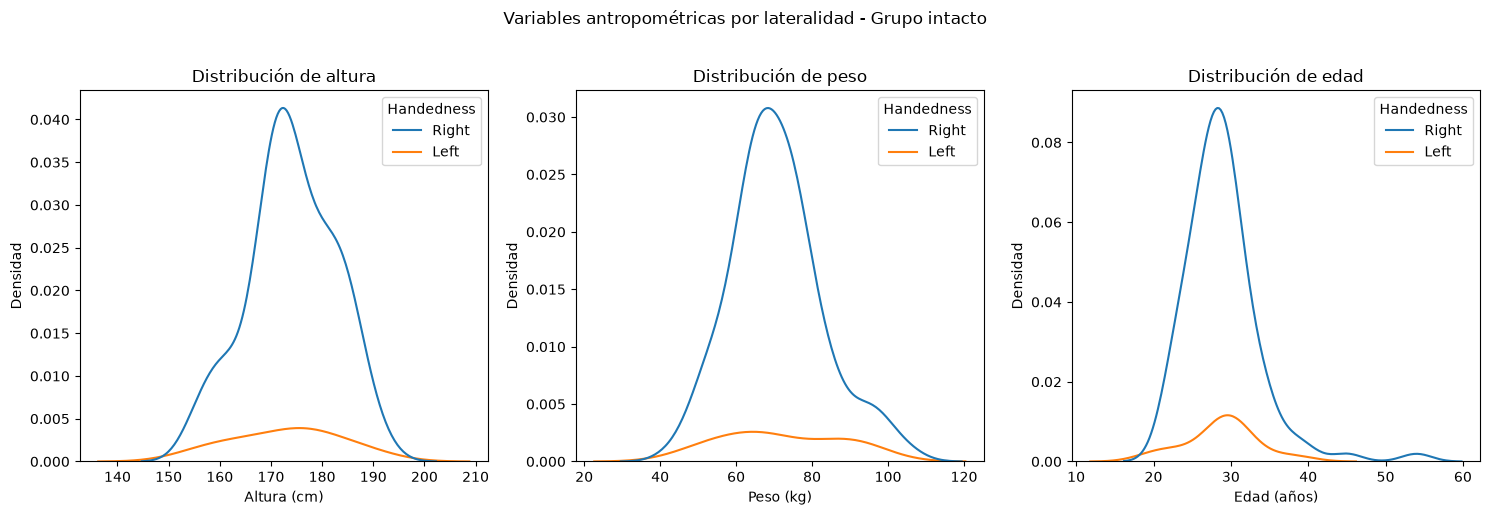

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.kdeplot(data=intact, x='Height', hue='Handedness', ax=axes[0])
axes[0].set_title('Distribución de altura')
axes[0].set_xlabel('Altura (cm)')
axes[0].set_ylabel('Densidad')

sns.kdeplot(data=intact, x='Weight', hue='Handedness', ax=axes[1])
axes[1].set_title('Distribución de peso')
axes[1].set_xlabel('Peso (kg)')
axes[1].set_ylabel('Densidad')

sns.kdeplot(data=intact, x='Age', hue='Handedness', ax=axes[2])
axes[2].set_title('Distribución de edad')
axes[2].set_xlabel('Edad (años)')
axes[2].set_ylabel('Densidad')

fig.suptitle('Variables antropométricas por lateralidad - Grupo intacto', y=1.02)
plt.tight_layout()

##### 3.3.1 Tabla resumen: media y desviación estándar por lateralidad

Esta tabla resume la distribución de edad, peso y altura agrupada únicamente por lateralidad, considerando todas las bases de datos de forma conjunta. Al estar la muestra habitualmente dominada por sujetos diestros, el grupo de zurdos puede tener un n bastante menor; por eso se deja visible en la tabla.


In [27]:
resumen_intact = intact.groupby('Handedness').agg(
    n=('Subject', 'count'),
    Edad_media=('Age', 'mean'), Edad_de=('Age', 'std'),
    Altura_media=('Height', 'mean'), Altura_de=('Height', 'std'),
    Peso_media=('Weight', 'mean'), Peso_de=('Weight', 'std'),
).round(1)
resumen_intact

,n,Edad_media,Edad_de,Altura_media,Altura_de,Peso_media,Peso_de
Handedness,,,,,,,
Left,13,28.8,4.5,172.8,10.5,71.8,15.2
Right,94,28.9,4.8,174.0,8.5,70.6,11.9


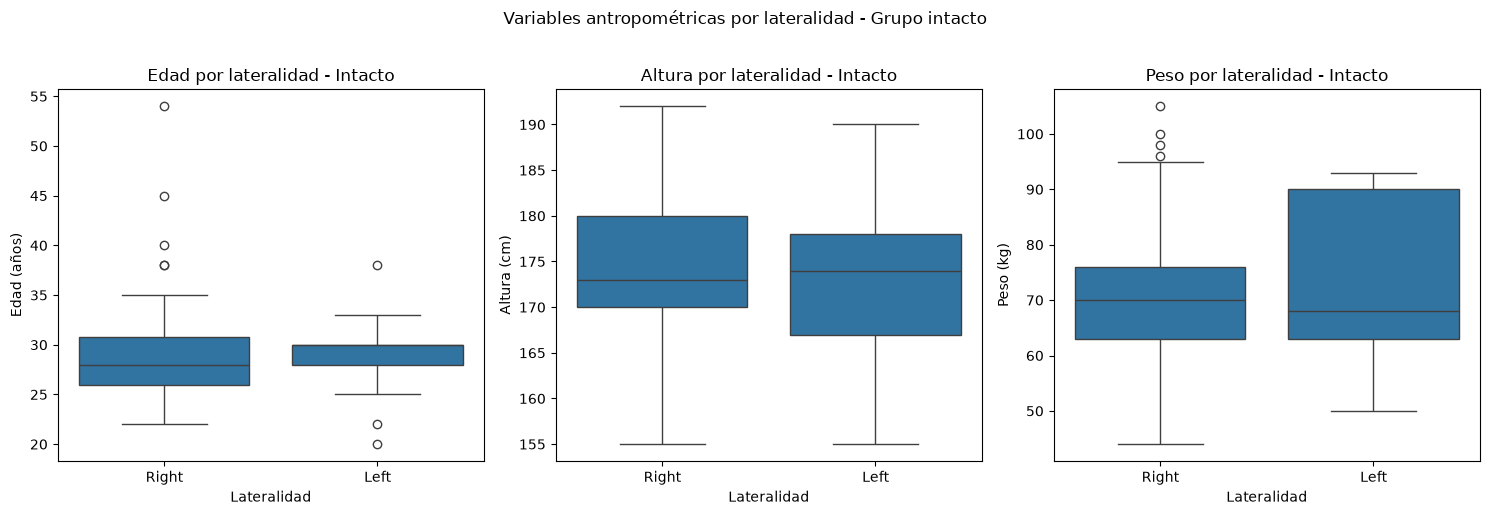

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.boxplot(x='Handedness', y='Age', data=intact, ax=axes[0])
sns.boxplot(x='Handedness', y='Height', data=intact, ax=axes[1])
sns.boxplot(x='Handedness', y='Weight', data=intact, ax=axes[2])

unidades = {'Edad': 'años', 'Altura': 'cm', 'Peso': 'kg'}
for ax, titulo in zip(axes, ['Edad', 'Altura', 'Peso']):
    ax.set_title(f'{titulo} por lateralidad - Intacto')
    ax.set_xlabel('Lateralidad')
    ax.set_ylabel(f'{titulo} ({unidades[titulo]})')

fig.suptitle('Variables antropométricas por lateralidad - Grupo intacto', y=1.02)
plt.tight_layout()

#### 3.4 Análisis estratificado por base de datos: perfil visual

Las muestras de sujetos intactos provienen de diferentes bases de datos. Esta subsección explora, de varias formas complementarias, si la procedencia introduce variaciones visibles en edad, peso, altura e IMC, y si esas variaciones se explican en parte por diferencias de composición (género, lateralidad, categoría de IMC) entre bases de datos. Las tablas de referencia con media y desviación estándar para el artículo se consolidan más adelante, en la sección 3.5.


##### 3.4.1 Distribución de variables por base de datos

Se comparan las cuatro variables numéricas (edad, altura, peso e IMC) entre bases de datos usando tres vistas complementarias: densidad (KDE), boxplot y violin plot. El violin plot es útil aquí porque, además de mostrar la mediana y el rango intercuartílico como el boxplot, deja ver la forma completa de la distribución en cada base de datos. Al final se añade la composición categórica (género, lateralidad, categoría de IMC) de cada base de datos, para verificar si las diferencias numéricas observadas podrían explicarse por un desbalance en estas variables.


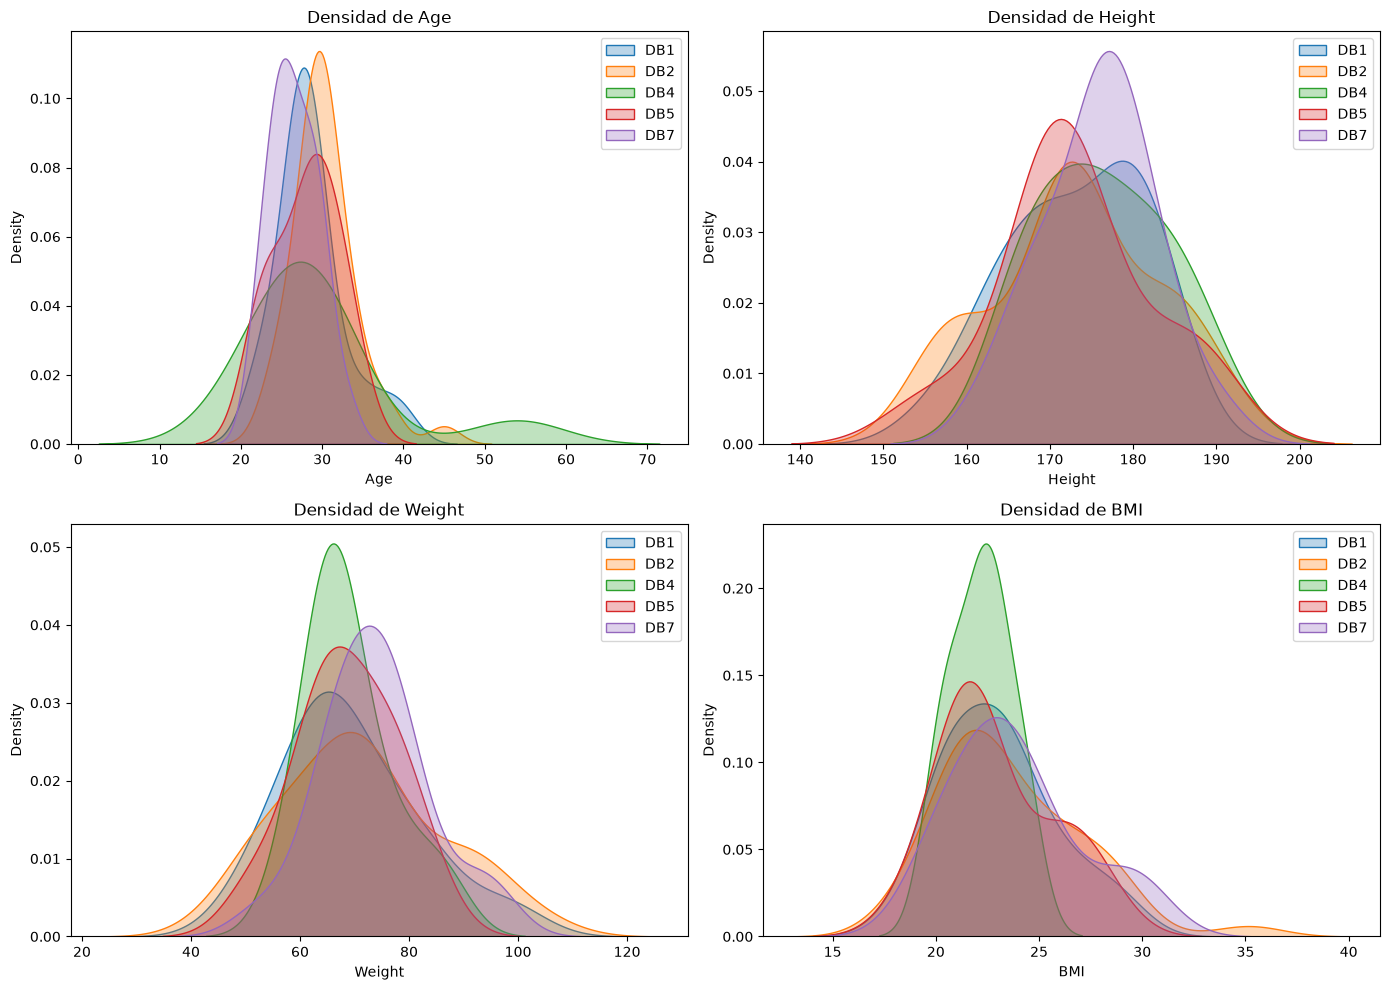

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, var in enumerate(['Age', 'Height', 'Weight', 'BMI']):
    ax = axes[i//2, i%2]
    for db in intact['Database'].unique():
        subset = intact[intact['Database'] == db]
        sns.kdeplot(data=subset[var], ax=ax, label=db, fill=True, alpha=0.3)
    ax.set_title(f'Densidad de {var}')
    ax.legend()
plt.tight_layout()
plt.show()

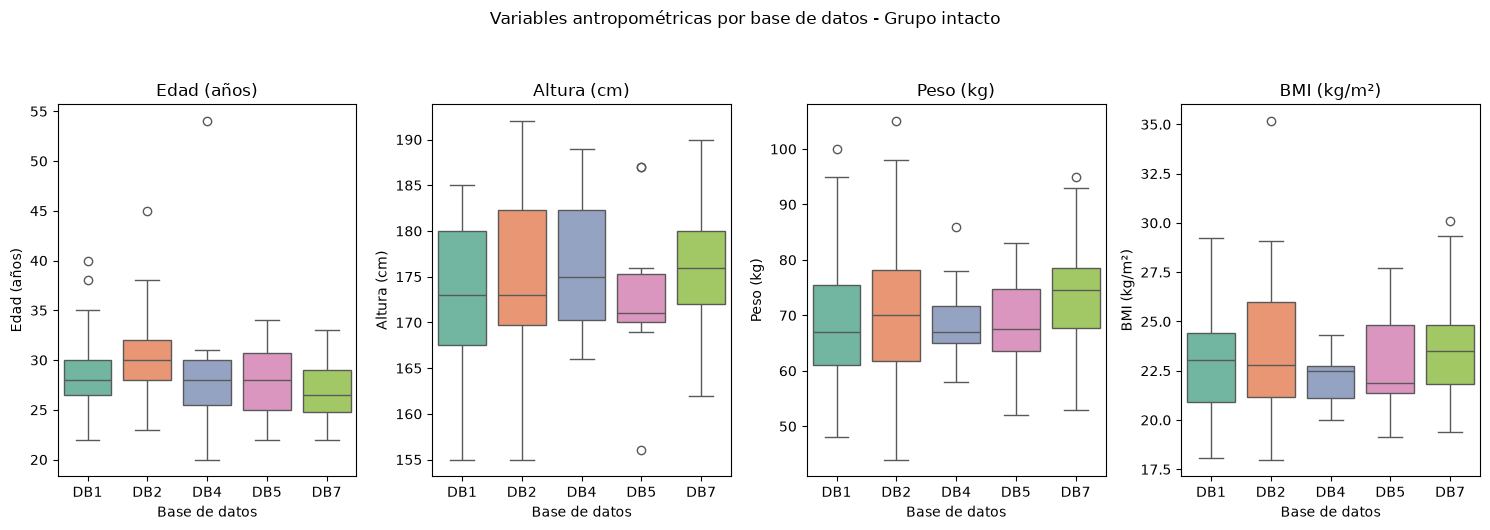

In [30]:
fig, axes = plt.subplots(1, 4, figsize=(15, 5))

sns.boxplot(x='Database', y='Age', hue='Database', data=intact, ax=axes[0], palette='Set2', legend=False)
sns.boxplot(x='Database', y='Height', hue='Database', data=intact, ax=axes[1], palette='Set2', legend=False)
sns.boxplot(x='Database', y='Weight', hue='Database', data=intact, ax=axes[2], palette='Set2', legend=False)
sns.boxplot(x='Database', y='BMI', hue='Database', data=intact, ax=axes[3], palette='Set2', legend=False)

titulos = ['Edad (años)', 'Altura (cm)', 'Peso (kg)', 'BMI (kg/m²)']
for ax, titulo in zip(axes, titulos):
    ax.set_title(titulo)
    ax.set_xlabel('Base de datos')
    ax.set_ylabel(titulo)

fig.suptitle('Variables antropométricas por base de datos - Grupo intacto', y=1.05)
plt.tight_layout()

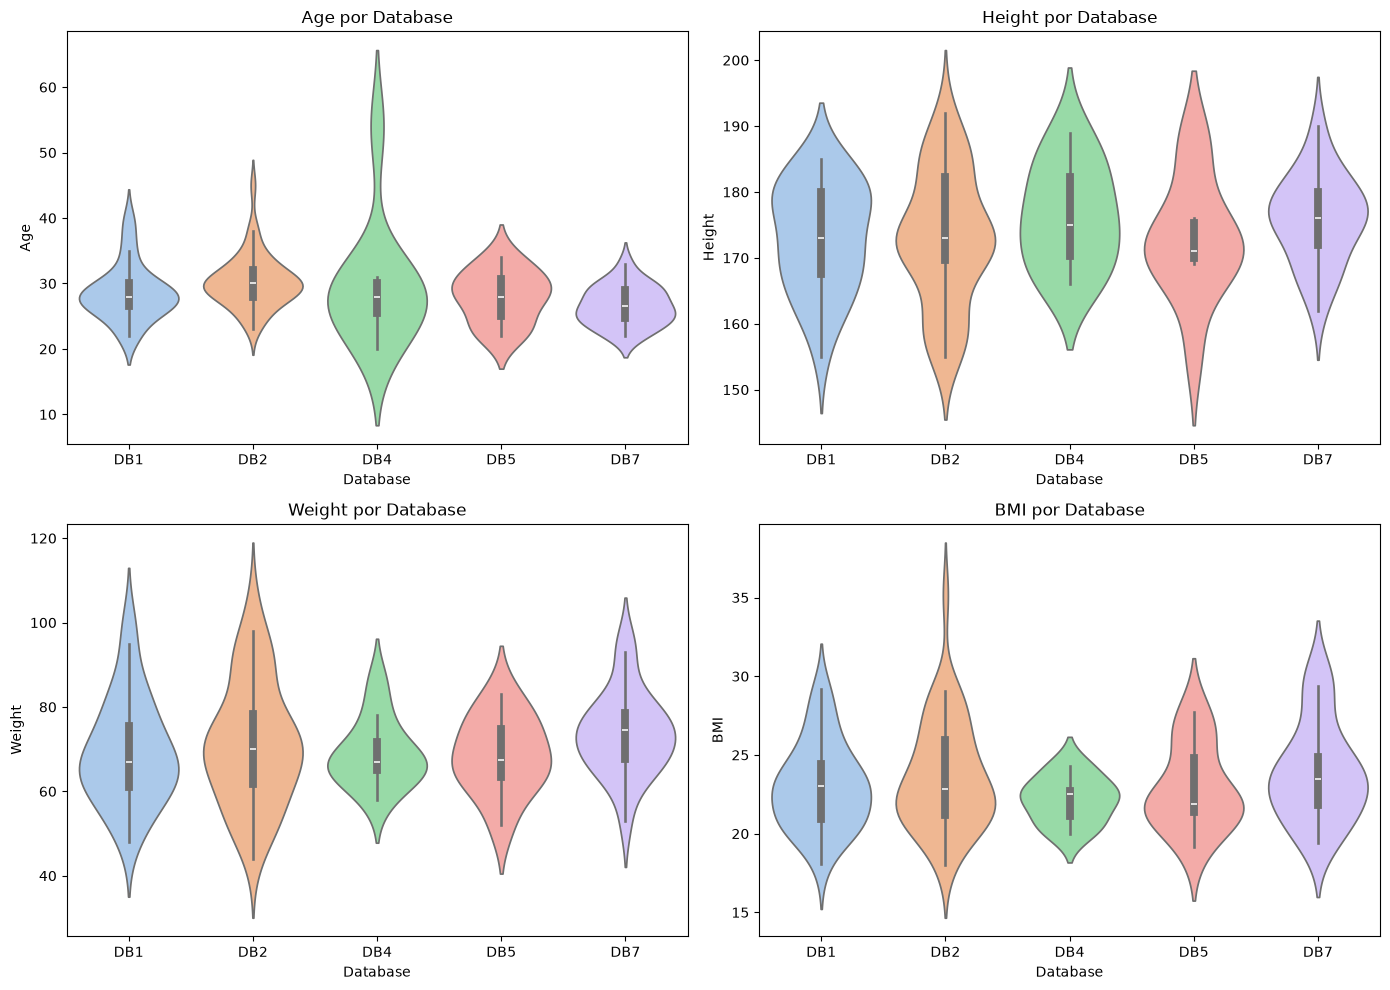

In [31]:
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    # Tu código aquí
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    for i, var in enumerate(['Age', 'Height', 'Weight', 'BMI']):
        ax = axes[i//2, i%2]
        sns.violinplot(data=intact, x='Database', y=var, ax=ax, palette='pastel')
        ax.set_title(f'{var} por Database')
    plt.tight_layout()
    plt.show()

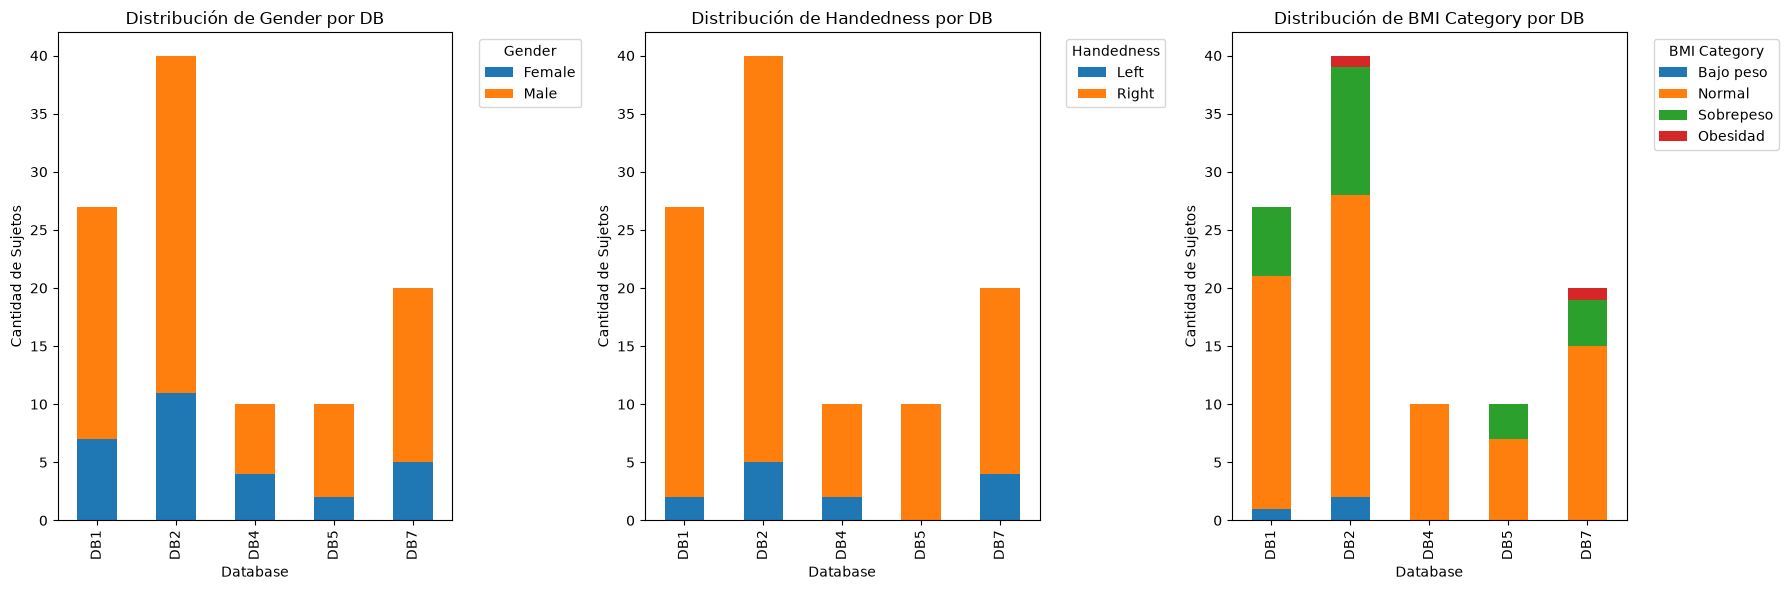

In [32]:
vars_to_plot = ['Gender', 'Handedness', 'BMI Category']
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, var in enumerate(vars_to_plot):
    ct = pd.crosstab(intact['Database'], intact[var])
    ct.plot(kind='bar', stacked=True, ax=axes[i])
    axes[i].set_title(f'Distribución de {var} por DB')
    axes[i].set_ylabel('Cantidad de Sujetos')
    axes[i].legend(title=var, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

##### 3.4.2 Perfil estadístico detallado por variable

A diferencia de las tablas de media y desviación estándar de la sección 3.5 (pensadas para citar en el artículo), aquí se muestra un detalle más completo por variable: mediana, mínimo y máximo además de la media y la desviación estándar. Esto es útil para detectar asimetrías o valores extremos dentro de una base de datos específica que una tabla resumida no dejaría ver.


In [33]:
# Tabla de estadísticos descriptivos por DB
stats_db = intact.groupby('Database')[['Age']].agg(['mean', 'median', 'std', 'min', 'max'])
stats_db.round(2)

Age                     
           mean median   std min max
Database                            
DB1       28.59   28.0  4.24  22  40
DB2       30.30   30.0  4.06  23  45
DB4       29.60   28.0  9.24  20  54
DB5       28.00   28.0  3.97  22  34
DB7       26.55   26.5  2.98  22  33

In [34]:
# Tabla de estadísticos descriptivos por DB
stats_db = intact.groupby('Database')[['Height']].agg(['mean', 'median', 'std', 'min', 'max'])
stats_db.round(2)

Height                       
            mean median   std  min  max
Database                               
DB1       173.15  173.0  8.26  155  185
DB2       172.98  173.0  9.96  155  192
DB4       176.30  175.0  7.83  166  189
DB5       173.00  171.0  9.03  156  187
DB7       175.90  176.0  6.79  162  190

In [35]:
# Tabla de estadísticos descriptivos por DB
stats_db = intact.groupby('Database')[['Weight']].agg(['mean', 'median', 'std', 'min', 'max'])
stats_db.round(2)

Weight                       
           mean median    std min  max
Database                              
DB1       69.41   67.0  12.53  48  100
DB2       71.25   70.0  14.59  44  105
DB4       69.00   67.0   8.06  58   86
DB5       68.60   67.5   9.11  52   83
DB7       73.75   74.5   9.94  53   95

In [36]:
# Tabla de estadísticos descriptivos por DB
stats_db = intact.groupby('Database')[['BMI']].agg(['mean', 'median', 'std', 'min', 'max'])
stats_db.round(2)

BMI                           
           mean median   std    min    max
Database                                  
DB1       23.01  23.03  2.76  18.07  29.22
DB2       23.64  22.81  3.49  17.99  35.16
DB4       22.15  22.50  1.45  20.01  24.31
DB5       22.93  21.88  2.70  19.16  27.73
DB7       23.85  23.50  3.11  19.39  30.12

##### 3.4.3 Comparación por género y base de datos

Se cruza la base de datos con el género para revisar si las diferencias observadas entre bases de datos en la sección 3.4.1 podrían deberse, al menos en parte, a que unas bases de datos tienen más proporción de un género que otras.


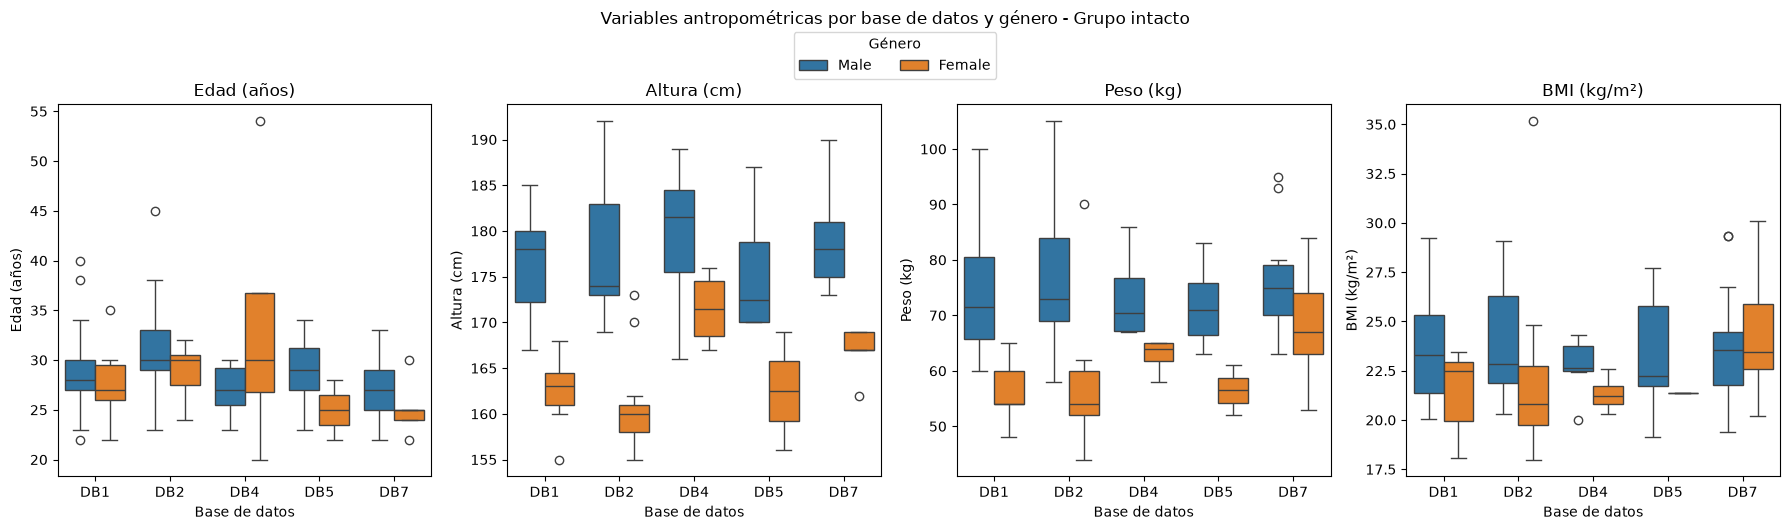

In [37]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

sns.boxplot(x='Database', y='Age', hue='Gender', data=intact, ax=axes[0])
sns.boxplot(x='Database', y='Height', hue='Gender', data=intact, ax=axes[1])
sns.boxplot(x='Database', y='Weight', hue='Gender', data=intact, ax=axes[2])
sns.boxplot(x='Database', y='BMI', hue='Gender', data=intact, ax=axes[3])

titulos = ['Edad (años)', 'Altura (cm)', 'Peso (kg)', 'BMI (kg/m²)']
for ax, titulo in zip(axes, titulos):
    ax.set_title(titulo)
    ax.set_xlabel('Base de datos')
    ax.set_ylabel(titulo)
    ax.get_legend().remove()  # Eliminar leyenda individual

# Leyenda general única
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Género', loc='upper center', 
           bbox_to_anchor=(0.5, 1.02), ncol=2)

fig.suptitle('Variables antropométricas por base de datos y género - Grupo intacto', y=1.05)
plt.tight_layout()

##### 3.4.4 Comparación por lateralidad y base de datos

De forma análoga a la subsección anterior, se cruza la base de datos con la lateralidad para revisar si el predominio de sujetos diestros se distribuye de forma pareja entre bases de datos o si alguna concentra una proporción distinta de zurdos.


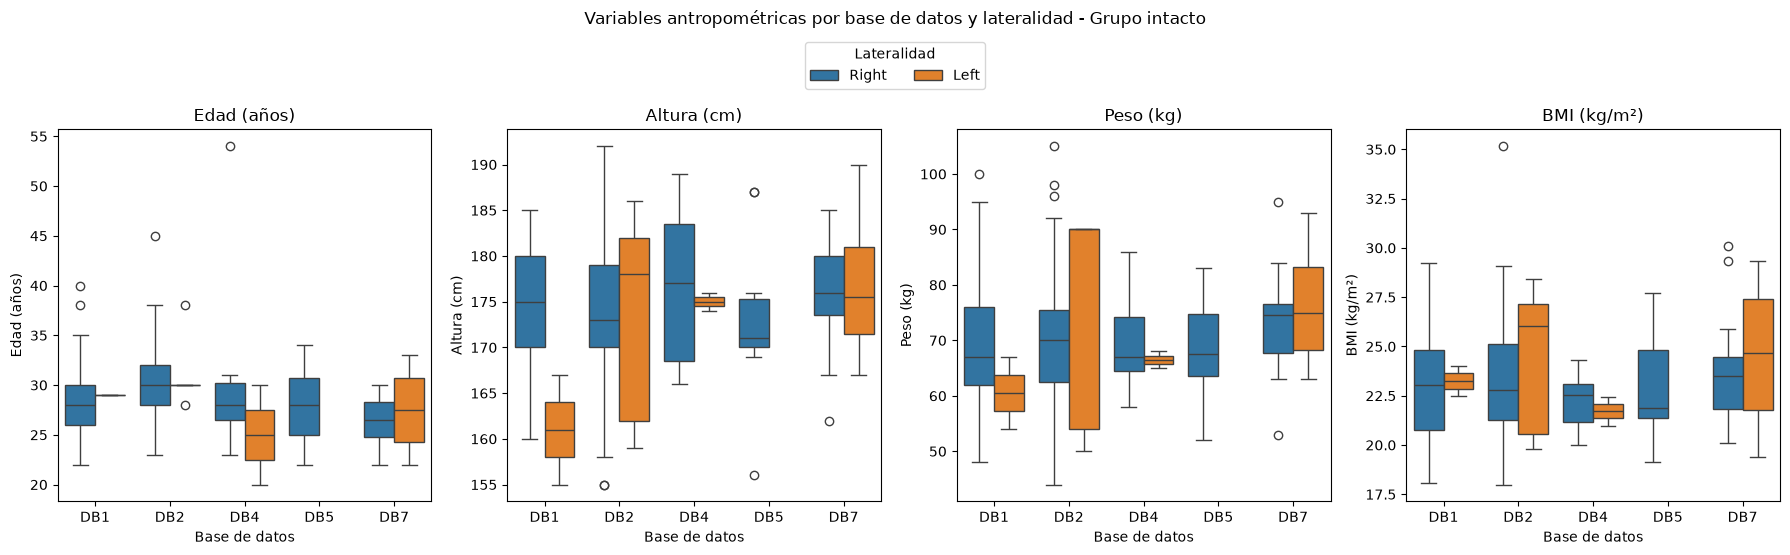

In [38]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

sns.boxplot(x='Database', y='Age', hue='Handedness', data=intact, ax=axes[0])
sns.boxplot(x='Database', y='Height', hue='Handedness', data=intact, ax=axes[1])
sns.boxplot(x='Database', y='Weight', hue='Handedness', data=intact, ax=axes[2])
sns.boxplot(x='Database', y='BMI', hue='Handedness', data=intact, ax=axes[3])

titulos = ['Edad (años)', 'Altura (cm)', 'Peso (kg)', 'BMI (kg/m²)']
for ax, titulo in zip(axes, titulos):
    ax.set_title(titulo)
    ax.set_xlabel('Base de datos')
    ax.set_ylabel(titulo)

# Obtener handles y labels antes de eliminar leyendas
handles, labels = axes[0].get_legend_handles_labels()

# Eliminar leyendas individuales
for ax in axes:
    ax.get_legend().remove()

# Crear leyenda general única
fig.legend(handles, labels, title='Lateralidad', loc='upper center',
           bbox_to_anchor=(0.5, 1.05), ncol=2)

fig.suptitle('Variables antropométricas por base de datos y lateralidad - Grupo intacto', y=1.1)
plt.tight_layout()

##### 3.4.5 Comparación por categoría de IMC y base de datos

Se cruza la base de datos con la categoría de IMC para revisar si el perfil nutricional de la muestra es consistente entre bases de datos o si alguna concentra más sujetos en una categoría particular (por ejemplo, más casos de sobrepeso).


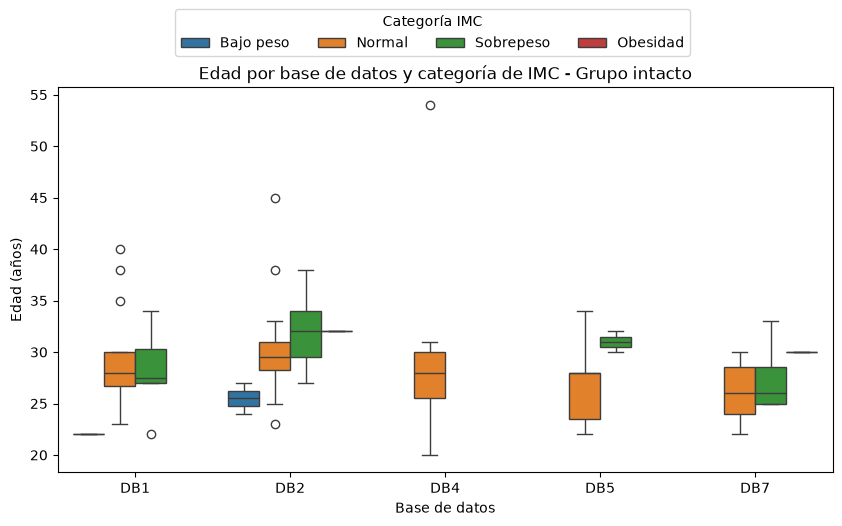

In [39]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(x='Database', y='Age', hue='BMI Category', data=intact, ax=ax)

ax.set_title('Edad por base de datos y categoría de IMC - Grupo intacto')
ax.set_xlabel('Base de datos')
ax.set_ylabel('Edad (años)')
ax.get_legend().remove()

# Leyenda general única
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, title='Categoría IMC', loc='upper center',
           bbox_to_anchor=(0.5, 1.05), ncol=4)

##### 3.4.6 Perfil radar por base de datos

Como cierre visual de esta subsección, se resumen las cuatro variables numéricas en un único gráfico de radar por base de datos. Esta vista no reemplaza a las anteriores, pero permite comparar de un solo vistazo el "perfil" promedio de cada base de datos en las cuatro dimensiones a la vez.


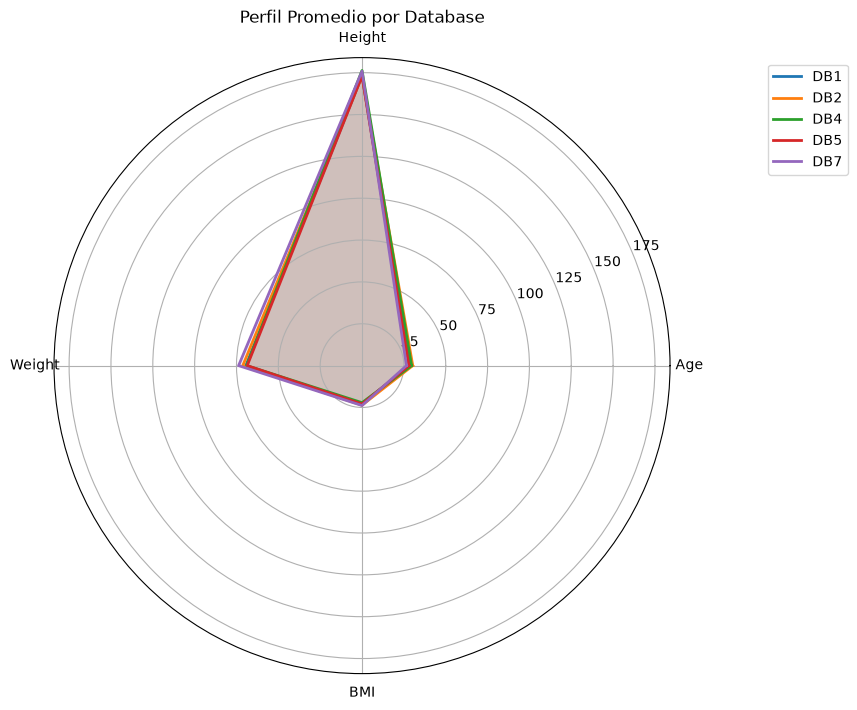

In [40]:
categories = ['Age', 'Height', 'Weight', 'BMI']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for db in intact['Database'].unique():
    values = intact[intact['Database'] == db][categories].mean().values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=db)
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_title('Perfil Promedio por Database')
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
plt.show()

#### 3.5 Tablas resumen por base de datos 

Se consolidan aquí las tablas de media y desviación estándar por base de datos, incluyendo el número de sujetos (n) en cada una. Se deja el n siempre visible porque las bases con pocos sujetos pueden mostrar medias poco estables, algo que debe advertirse antes de comparar valores entre filas.


##### 3.5.1 Media y desviación estándar por base de datos

Tabla de referencia general: resume edad, peso y altura por base de datos, sin ningún otro cruce adicional.


In [41]:
resumen_intact = intact.groupby('Database').agg(
    n=('Subject', 'count'),
    Edad_media=('Age', 'mean'), Edad_de=('Age', 'std'),
    Altura_media=('Height', 'mean'), Altura_de=('Height', 'std'),
    Peso_media=('Weight', 'mean'), Peso_de=('Weight', 'std'),
).round(1)
resumen_intact


,n,Edad_media,Edad_de,Altura_media,Altura_de,Peso_media,Peso_de
Database,,,,,,,
DB1,27,28.6,4.2,173.1,8.3,69.4,12.5
DB2,40,30.3,4.1,173.0,10.0,71.2,14.6
DB4,10,29.6,9.2,176.3,7.8,69.0,8.1
DB5,10,28.0,4.0,173.0,9.0,68.6,9.1
DB7,20,26.6,3.0,175.9,6.8,73.8,9.9


##### 3.5.2 Media y desviación estándar por base de datos y género

Esta tabla desglosa la anterior por género dentro de cada base de datos. El objetivo es identificar si existen diferencias de composición entre géneros dentro de cada estudio y verificar si el equilibrio entre categorías es consistente entre bases de datos. Algunas bases pueden tener proporciones desbalanceadas de género, lo cual debe considerarse al interpretar comparaciones entre grupos.


In [42]:
resumen_intact = intact.groupby(['Database', 'Gender']).agg(
    n=('Subject', 'count'),
    Edad_media=('Age', 'mean'), Edad_de=('Age', 'std'),
    Altura_media=('Height', 'mean'), Altura_de=('Height', 'std'),
    Peso_media=('Weight', 'mean'), Peso_de=('Weight', 'std'),
).round(1)
resumen_intact

n  Edad_media  Edad_de  Altura_media  Altura_de  Peso_media  \
Database Gender                                                                 
DB1      Female   7        27.9      4.1         162.4        4.1        56.4   
         Male    20        28.8      4.4         176.9        5.6        74.0   
DB2      Female  11        29.0      2.5         160.9        5.7        57.3   
         Male    29        30.8      4.5         177.6        6.9        76.6   
DB4      Female   4        33.5     14.5         171.5        4.2        62.8   
         Male     6        27.0      2.8         179.5        8.3        73.2   
DB5      Female   2        25.0      4.2         162.5        9.2        56.5   
         Male     8        28.8      3.8         175.6        7.3        71.6   
DB7      Female   5        25.2      2.9         166.8        2.9        68.2   
         Male    15        27.0      3.0         178.9        4.6        75.6   

                 Peso_de  
Database Gender           
DB1      Female      5.6  
         Male       11.0  
DB2      Female     12.0  
         Male       11.8  
DB4      Female      3.3  
         Male        7.6  
DB5      Female      6.4  
         Male        7.0  
DB7      Female     11.6  
         Male        9.0

##### 3.5.3 Media y desviación estándar por base de datos y categoría de IMC

Esta tabla desglosa la anterior por categoría de IMC dentro de cada base de datos. El objetivo es identificar si existen diferencias de composición según el estado nutricional dentro de cada estudio y verificar si la distribución de categorías de IMC es consistente entre bases de datos. Algunas bases pueden tener proporciones desbalanceadas de IMC, lo cual debe considerarse al interpretar comparaciones antropométricas entre grupos.


In [43]:
resumen_intact = intact.groupby(['Database', 'BMI Category']).agg(
    n=('Subject', 'count'),
    Edad_media=('Age', 'mean'), Edad_de=('Age', 'std'),
    Altura_media=('Height', 'mean'), Altura_de=('Height', 'std'),
    Peso_media=('Weight', 'mean'), Peso_de=('Weight', 'std'),
).round(1)
resumen_intact

n  Edad_media  Edad_de  Altura_media  Altura_de  \
Database BMI Category                                                     
DB1      Bajo peso      1        22.0      NaN         163.0        NaN   
         Normal        20        29.0      4.2         171.8        8.0   
         Sobrepeso      6        28.2      4.1         179.2        6.2   
DB2      Bajo peso      2        25.5      2.1         162.5       10.6   
         Normal        26        29.9      4.2         171.3        9.6   
         Sobrepeso     11        31.9      3.4         179.9        7.0   
         Obesidad       1        32.0      NaN         160.0        NaN   
DB4      Normal        10        29.6      9.2         176.3        7.8   
DB5      Normal         7        26.7      4.1         173.6       11.0   
         Sobrepeso      3        31.0      1.0         171.7        1.5   
DB7      Normal        15        26.1      2.8         176.7        7.1   
         Sobrepeso      4        27.5      3.8         175.0        5.0   
         Obesidad       1        30.0      NaN         167.0        NaN   

                       Peso_media  Peso_de  
Database BMI Category                       
DB1      Bajo peso           48.0      NaN  
         Normal              65.2      7.3  
         Sobrepeso           87.0      9.1  
DB2      Bajo peso           48.0      5.7  
         Normal              65.0      8.0  
         Sobrepeso           88.6      9.4  
         Obesidad            90.0      NaN  
DB4      Normal              69.0      8.1  
DB5      Normal              64.4      7.1  
         Sobrepeso           78.3      4.5  
DB7      Normal              69.9      7.0  
         Sobrepeso           85.5     10.1  
         Obesidad            84.0      NaN

##### 3.5.4 Media y desviación estándar por base de datos y lateralidad

Esta tabla desglosa las variables antropométricas por lateralidad dentro de cada base de datos. El objetivo es identificar si existen diferencias de composición entre diestros y zurdos dentro de cada estudio y verificar si la distribución de lateralidad es consistente entre bases de datos. Algunas bases pueden tener proporciones desbalanceadas de lateralidad, lo cual debe considerarse al interpretar comparaciones antropométricas entre grupos.


In [44]:
resumen_intact = intact.groupby(['Database', 'Handedness']).agg(
    n=('Subject', 'count'),
    Edad_media=('Age', 'mean'), Edad_de=('Age', 'std'),
    Altura_media=('Height', 'mean'), Altura_de=('Height', 'std'),
    Peso_media=('Weight', 'mean'), Peso_de=('Weight', 'std'),
).round(1)
resumen_intact

n  Edad_media  Edad_de  Altura_media  Altura_de  \
Database Handedness                                                     
DB1      Left         2        29.0      0.0         161.0        8.5   
         Right       25        28.6      4.4         174.1        7.6   
DB2      Left         5        31.2      3.9         173.4       12.2   
         Right       35        30.2      4.1         172.9        9.8   
DB4      Left         2        25.0      7.1         175.0        1.4   
         Right        8        30.8      9.8         176.6        8.8   
DB5      Right       10        28.0      4.0         173.0        9.0   
DB7      Left         4        27.5      4.9         177.0        9.8   
         Right       16        26.3      2.5         175.6        6.2   

                     Peso_media  Peso_de  
Database Handedness                       
DB1      Left              60.5      9.2  
         Right             70.1     12.6  
DB2      Left              74.8     20.9  
         Right             70.7     13.8  
DB4      Left              66.5      2.1  
         Right             69.6      9.0  
DB5      Right             68.6      9.1  
DB7      Left              76.5     13.0  
         Right             73.1      9.4

## 4. Análisis multivariado

Las secciones anteriores compararon las variables antropométricas de a una o de a dos frente a una variable categórica. Esta sección cierra el EDA observando las cuatro variables numéricas (edad, altura, peso e IMC) en conjunto, para detectar relaciones y agrupamientos que no son evidentes al mirar cada variable por separado.


#### 4.1 Relación entre variables

Se usa un pairplot para visualizar, en una sola figura, la relación entre cada par de variables numéricas y su distribución individual, coloreando por base de datos. Esto permite detectar de un vistazo tanto correlaciones entre variables como posibles agrupamientos por base de datos. El scatterplot posterior profundiza en una relación puntual (edad vs. IMC), añadiendo género como variable adicional mediante el color.


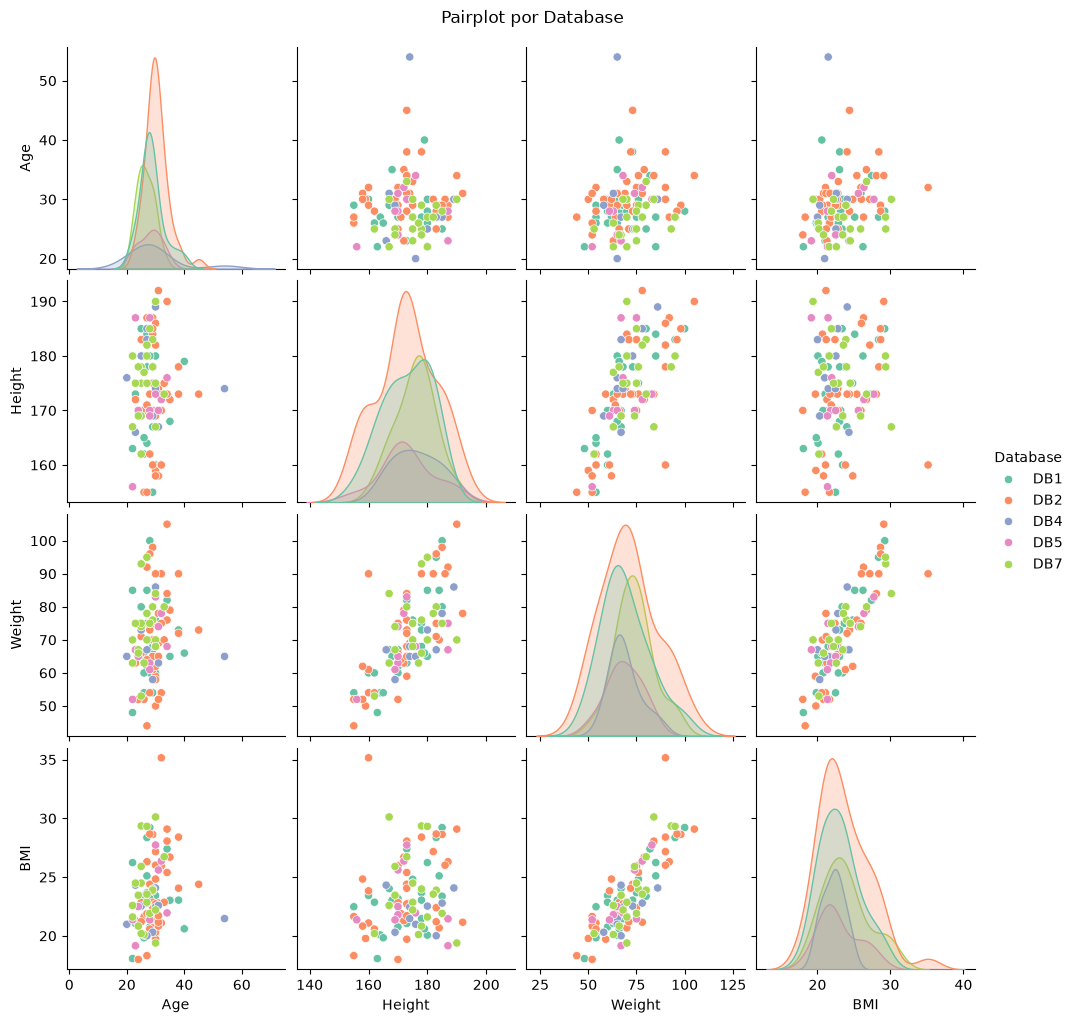

In [45]:
sns.pairplot(intact[['Age', 'Height', 'Weight', 'BMI', 'Database']], 
             hue='Database', diag_kind='kde', palette='Set2')
plt.suptitle('Pairplot por Database', y=1.02)
plt.show()

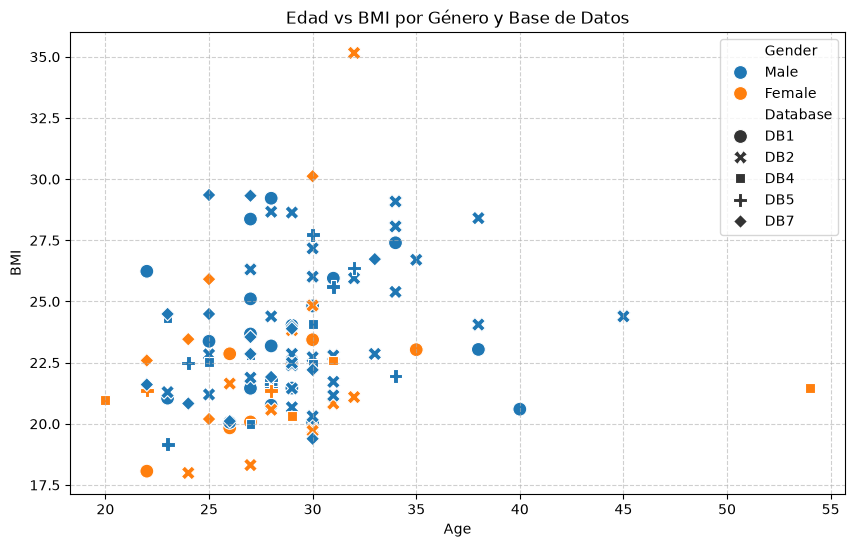

In [46]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=intact, x='Age', y='BMI', hue='Gender', style='Database', s=100)
plt.title('Edad vs BMI por Género y Base de Datos')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#### 4.2 Reducción dimensional (PCA)

El Análisis de Componentes Principales (PCA) resume las cuatro variables numéricas (estandarizadas previamente) en un número menor de componentes que capturan la mayor parte de la varianza. Es útil aquí para revisar, en un solo plano (o volumen), si los sujetos se agrupan visualmente según su base de datos de origen cuando se consideran las cuatro variables antropométricas a la vez.


##### 4.2.1 Proyección en dos componentes

Se proyectan los sujetos sobre los dos primeros componentes principales (PC1 y PC2). El porcentaje de varianza explicada por cada componente indica cuánta información del conjunto original de cuatro variables se conserva en esta proyección; cuanto más alto, más representativa es la vista 2D del perfil antropométrico completo.


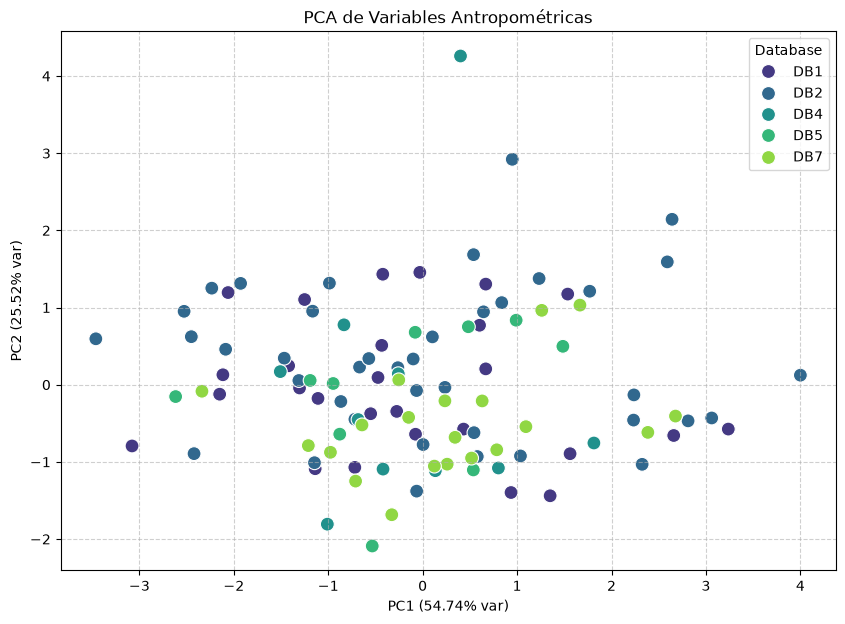

In [47]:
features = ['Age', 'Height', 'Weight', 'BMI']
x = intact[features]
x_scaled = StandardScaler().fit_transform(x)

pca = PCA(n_components=2)
components = pca.fit_transform(x_scaled)
pca_df = pd.DataFrame(data=components, columns=['PC1', 'PC2'])
pca_df['Database'] = intact['Database'].values

plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Database', s=100, palette='viridis')
plt.title('PCA de Variables Antropométricas')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} var)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

##### 4.2.2 Proyección en tres componentes

Se añade un tercer componente principal para revisar si incluir una dimensión adicional deja ver una separación entre bases de datos que no era evidente en la proyección 2D anterior.


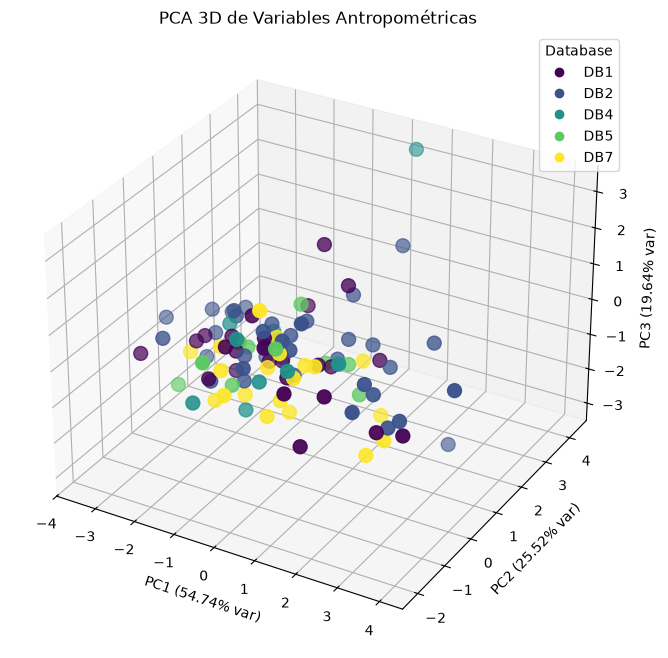

In [48]:
from mpl_toolkits.mplot3d import Axes3D

features = ['Age', 'Height', 'Weight', 'BMI']
x = intact[features]
x_scaled = StandardScaler().fit_transform(x)

pca = PCA(n_components=3)
components = pca.fit_transform(x_scaled)
pca_df = pd.DataFrame(data=components, columns=['PC1', 'PC2', 'PC3'])
pca_df['Database'] = intact['Database'].values

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    pca_df['PC1'], pca_df['PC2'], pca_df['PC3'],
    c=pca_df['Database'].astype('category').cat.codes,
    cmap='viridis', s=100, depthshade=True
)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} var)')
ax.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]:.2%} var)')
ax.set_title('PCA 3D de Variables Antropométricas')

# Leyenda
handles, _ = scatter.legend_elements()
ax.legend(handles, intact['Database'].unique(), title='Database')

plt.show()